In [1]:
import numpy as np
import pandas as pd
from ast import literal_eval
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from tqdm.auto import tqdm
from sklearn.base import clone
import optuna
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
class_to_int = {
     "tiny": 1,
     "small" : 2,
     "medium" : 3,
     "large" : 4,
     "huge" : 5,
     "gargantuan" : 6,
}
def preprocess_df(df_orig, flag_type, flag_unique, flag_else):
    df = df_orig.copy()
    for stat in ['Str', 'Dex', 'Con', 'Int', 'Wis', 'Cha']:
        df[stat] = (df[f'{stat} Mod'] + df[f'{stat} Save']) // 2 + df['PB']
        df.drop(columns=[f'{stat} Mod', f'{stat} Save', f'{stat} Prof'], inplace=True)
    if flag_unique:
        df = df[(df['Legendary'] != 'N') | (df['Category'] != 'unique')]
    df.drop(columns = ['Book', 'Page', 'Category','XP', 'PB', 'AC', 'HP', 'AB', 'DPR', 'Legendary',
                       'Restrained', 'Deafened', 'Frightened', 'Petrified', 'adj DPR', 'adj AB'], inplace=True)
    df.rename(columns={'adj AC': 'AC', 'adj HP': 'HP'}, inplace=True)
    df['Save DC'] = df['Save DC'].fillna(1)
    if flag_else==2:
        df['Size'] = df['Size'].map(class_to_int)
    else:
        df = pd.get_dummies(df, columns=['Size'], dtype=int, drop_first=flag_else)
    df['Saves quantity'] = df['AC adjustments'].apply(func=extract_saves_quantity)
    df['Saves quantity'] = df['Saves quantity'].fillna(0)
    mlb = MultiLabelBinarizer()
    df = df.join(pd.DataFrame(mlb.fit_transform(df.pop('AC adjustments')), index=df.index, columns=mlb.classes_))
    df = pd.get_dummies(df, columns=['Type'], dtype=int, drop_first=flag_type)
    df = df.convert_dtypes()
    return df
def extract_saves_quantity(dflist):
    for n in range(1,7):
        quan = f'{n} saves'
        if quan in dflist:
            dflist.remove(quan)
            return n

In [3]:
df = pd.read_csv('/kaggle/input/monsters (1).csv', converters={'AC adjustments': literal_eval})
df

,Book,Page,Type,Size,Category,Legendary,CR,PB,XP,Str Mod,...,AC,adj AC,HP,adj HP,AC adjustments,AB,adj AB,DPR,adj DPR,Save DC
0,SKT,188.0,humanoid,medium,generic,N,0.125,2,25.0,0.0,...,12.0,12.0,6.0,6.0,[],4.0,4.0,5.50000,6.666666,NaN
1,MM,12.0,humanoid,medium,generic,N,0.250,2,50.0,0.0,...,12.0,12.0,13.5,13.5,[],4.0,4.0,5.50000,6.666666,NaN
2,SAiS:BAM,8.0,plant,large,generic,N,3.000,2,700.0,4.0,...,16.0,16.0,75.0,75.0,[],NaN,NaN,NaN,NaN,NaN
3,SAiS:BAM,9.0,plant,medium,generic,N,2.000,2,450.0,1.0,...,14.0,14.0,52.0,52.0,[],NaN,NaN,NaN,NaN,NaN
4,SAiS:BAM,9.0,plant,medium,generic,N,2.000,2,450.0,2.0,...,15.0,15.0,38.5,38.5,[],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,VRGtR,255.0,undead,medium,generic,N,4.000,2,1100.0,3.0,...,10.0,11.0,78.0,85.0,[],5.0,5.0,31.00000,31.000000,12.0
1900,ToA,241.0,monstrosity,small,generic,N,0.500,2,100.0,1.0,...,10.0,12.0,27.0,27.0,"[magic resistance, shield]",3.0,3.0,8.00000,8.000000,NaN
1901,MPMotM,282.0,fiend,large,unique,LL,23.000,7,50000.0,6.0,...,18.0,22.0,304.0,548.8,"[3 saves, magic resistance]",13.0,13.0,144.00000,144.000000,NaN
1902,MToF,157.0,fiend,large,legacy,LL,23.000,7,50000.0,6.0,...,18.0,22.0,304.0,548.8,"[3 saves, magic resistance]",13.0,13.0,168.00000,168.000000,NaN


In [4]:
params = [(0,0,0), (0,0,1), (0,0,2), (0,1,0), (0,1,1), (0,1,2), (1,0,0), (1,0,1), (1,0,2), (1,1,0),
        (1,1,1), (1,1,2)]
best_mse = 1000000
best_setup = ''
arr1 = ['one-hot Type;', 'dummy Type;']
arr2 = ['all uniq;', 'skip non-L uniq;']
arr3 = ['one-hot Size;', 'dummy Size;', 'label Size;']
for param in tqdm(params, desc="Перебор вариантов предобработки"):
    print('===================================')
    print(arr1[param[0]], arr2[param[1]], arr3[param[2]])
    df_clean = preprocess_df(df, *param)
    train_val, test = train_test_split(df_clean, test_size=0.2, random_state=54)
    X = train_val.drop('CR', axis=1)
    y = train_val['CR']
    preprocessors = [StandardScaler(), MinMaxScaler()]
    models = [LinearRegression(), SVR(kernel='linear'), SVR(kernel='poly'), SVR(kernel='rbf'), DecisionTreeRegressor(),
              RandomForestRegressor(), GradientBoostingRegressor(), KNeighborsRegressor(), xgb.XGBRegressor()]
    for prep in preprocessors:
        print('--------------------------------------')
        print(f'Using preprocessor {prep}:')
        for model in models:
            N_SPLITS = 5
            kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=54)
            fold_mses = []
            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
                prep_ex = clone(prep)
                model_ex = clone(model)
                X_train_scaled = prep_ex.fit_transform(X_train)
                X_val_scaled = prep_ex.transform(X_val)
                model_ex.fit(X_train_scaled, y_train)
                y_pred_val = model_ex.predict(X_val_scaled)
                fold_mses.append(mean_squared_error(y_val, y_pred_val))
            avg_mse_for_combo = np.mean(fold_mses) 
            if avg_mse_for_combo < best_mse:
                best_mse = avg_mse_for_combo
                best_setup = {
                    'model_class': model,
                    'preprocessor_class': prep,
                    'preprocessing_params': param
                }
                best_setup_txt = f'Model: {model}. Preprocessor: {prep}. {arr1[param[0]]} {arr2[param[1]]} {arr3[param[2]]}'
            print(f'Model: {model}')
            print(f'MSE: {avg_mse_for_combo}')
            print('--------------------------------------')
            
print(best_mse, best_setup)

Перебор вариантов предобработки:   0%|          | 0/12 [00:00<?, ?it/s]

one-hot Type; all uniq; one-hot Size;
--------------------------------------
Using preprocessor StandardScaler():
Model: LinearRegression()
MSE: 1.6393287959074897e+23
--------------------------------------
Model: SVR(kernel='linear')
MSE: 2.1008817717567467
--------------------------------------
Model: SVR(kernel='poly')
MSE: 7.616094178929108
--------------------------------------
Model: SVR()
MSE: 5.757623476651611
--------------------------------------
Model: DecisionTreeRegressor()
MSE: 2.6216242263145912
--------------------------------------
Model: RandomForestRegressor()
MSE: 1.2908999745784118
--------------------------------------
Model: GradientBoostingRegressor()
MSE: 1.3255472620922337
--------------------------------------
Model: KNeighborsRegressor()
MSE: 6.295206399644089
--------------------------------------
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None,

In [5]:
df_final = preprocess_df(df, *best_setup['preprocessing_params'])
train_val, test = train_test_split(df_final, test_size=0.2, random_state=54)
prep = best_setup['preprocessor_class']
y_train_val = train_val['CR']
X_train_val_raw = train_val.drop('CR', axis=1)
y_test = test['CR']
X_test_raw = test.drop('CR', axis=1)
X_train_val = prep.fit_transform(X_train_val_raw)
X_test = prep.transform(X_test_raw)


def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1.0),
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'random_state': 54,
        'n_jobs': -1
    }
    model = xgb.XGBRegressor(**param)
    scores = cross_val_score(
        model,
        X_train_val,
        y_train_val,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    mse = -np.mean(scores)
    return mse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_trial = study.best_trial
print(f" Лучшее значение MSE: {best_trial.value}")
print("  Лучшие параметры: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")
best_params = best_trial.params
final_model = xgb.XGBRegressor(**best_params, random_state=54)
final_model.fit(X_train_val, y_train_val)
y_pred = final_model.predict(X_test)
final_mse = mean_squared_error(y_test, y_pred)
print(f'\nЗначение MSE на тестовой выборке: {final_mse}')

[I 2025-06-17 00:10:42,633] A new study created in memory with name: no-name-0ea433dc-0326-467e-bcf1-0022684ad22e
[I 2025-06-17 00:10:44,854] Trial 0 finished with value: 1.1057608370345726 and parameters: {'n_estimators': 239, 'max_depth': 5, 'learning_rate': 0.28995529750126725, 'subsample': 0.8909334387923273, 'colsample_bytree': 0.6459815978163759, 'gamma': 0.22209425068952926}. Best is trial 0 with value: 1.1057608370345726.
[I 2025-06-17 00:10:45,269] Trial 1 finished with value: 1.0814607005600931 and parameters: {'n_estimators': 414, 'max_depth': 5, 'learning_rate': 0.06252771449713591, 'subsample': 0.7501505071904296, 'colsample_bytree': 0.9423365068485283, 'gamma': 0.8315177613010271}. Best is trial 1 with value: 1.0814607005600931.
[I 2025-06-17 00:10:45,571] Trial 2 finished with value: 1.1954855636578277 and parameters: {'n_estimators': 404, 'max_depth': 7, 'learning_rate': 0.29486366003901743, 'subsample': 0.694216805788232, 'colsample_bytree': 0.6482940381873704, 'gamma'

 Лучшее значение MSE: 0.9636921248580107
  Лучшие параметры: 
    n_estimators: 386
    max_depth: 6
    learning_rate: 0.06328633026948145
    subsample: 0.9002466732854305
    colsample_bytree: 0.6371082324193003
    gamma: 6.965498431149575e-05

Значение MSE на тестовой выборке: 1.0310945022003284


In [6]:
mse_scores = []
N_ITERATIONS = 1000

for i in tqdm(range(N_ITERATIONS), desc="Монте Карло"):
    train_val, test = train_test_split(df_final, test_size=0.2) 
    y_train_val = train_val['CR']
    X_train_val_raw = train_val.drop('CR', axis=1)
    y_test = test['CR']
    X_test_raw = test.drop('CR', axis=1)
    prep_iter = clone(best_setup['preprocessor_class'])
    X_train_val_scaled = prep_iter.fit_transform(X_train_val_raw)
    X_test_scaled = prep_iter.transform(X_test_raw)
    model_iter = xgb.XGBRegressor(**best_params, random_state=54)
    model_iter.fit(X_train_val_scaled, y_train_val)
    y_pred = model_iter.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)

Монте Карло:   0%|          | 0/1000 [00:00<?, ?it/s]


Результаты Монте Карло:
Среднее MSE по 1000 запускам: 0.9301
Стандартное отклонение MSE: 0.1258
Медианное MSE: 0.9194


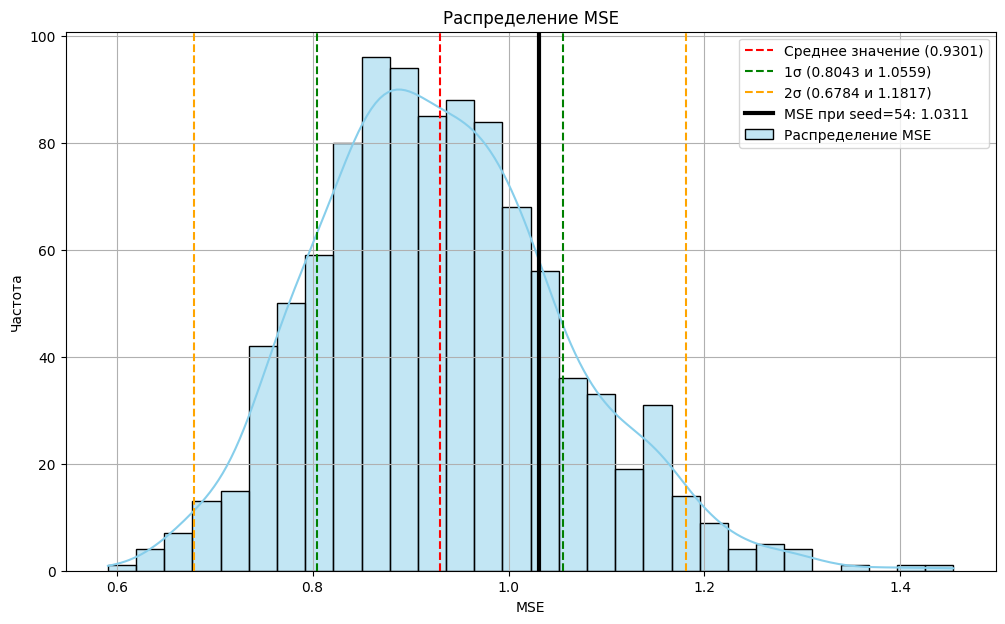

In [8]:
mse_scores = np.array(mse_scores)
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
median_mse = np.median(mse_scores)

print("\nРезультаты Монте Карло:")
print(f"Среднее MSE по {N_ITERATIONS} запускам: {mean_mse:.4f}")
print(f"Стандартное отклонение MSE: {std_mse:.4f}")
print(f"Медианное MSE: {median_mse:.4f}")

plt.figure(figsize=(12, 7))
sns.histplot(mse_scores, kde=True, bins=30, color='skyblue', label='Распределение MSE')

plt.axvline(mean_mse, color='red', linestyle='--', 
            label=f'Среднее значение ({mean_mse:.4f})')

sigma1_lower = mean_mse - std_mse
sigma1_upper = mean_mse + std_mse
plt.axvline(sigma1_lower, color='green', linestyle='--')
plt.axvline(sigma1_upper, color='green', linestyle='--', 
            label=f'1σ ({sigma1_lower:.4f} и {sigma1_upper:.4f})')

sigma2_lower = mean_mse - 2 * std_mse
sigma2_upper = mean_mse + 2 * std_mse
plt.axvline(sigma2_lower, color='orange', linestyle='--')
plt.axvline(sigma2_upper, color='orange', linestyle='--', 
            label=f'2σ ({sigma2_lower:.4f} и {sigma2_upper:.4f})')

plt.axvline(final_mse, color='black', linestyle='-', linewidth=3, 
            label=f'MSE при seed=54: {final_mse:.4f}')

plt.title('Распределение MSE')
plt.xlabel('MSE')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()